# 1. load and understand the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Attrition_dataset.csv')

In [5]:
df

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49648,8258,12/1/2015 0:00,5/28/1994,8/19/2013,12/30/2015,21,2,Valemount,Dairy,Dairy Person,34,M,Male,Layoff,Involuntary,2015,TERMINATED,STORES
49649,8264,8/1/2013 0:00,6/13/1994,8/27/2013,8/30/2013,19,0,Vancouver,Customer Service,Cashier,44,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
49650,8279,12/1/2015 0:00,7/18/1994,9/15/2013,12/30/2015,21,2,White Rock,Customer Service,Cashier,39,F,Female,Layoff,Involuntary,2015,TERMINATED,STORES
49651,8296,12/1/2013 0:00,9/2/1994,10/9/2013,12/31/2013,19,0,Kelowna,Customer Service,Cashier,16,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES




# 2. clean the dataset

1. check for duplicates and remove them

2. check for missing values and handle them/remove them

3. check for invalid datatypes and handle them

4. remove any unwanted columns


In [6]:
# checking for dupilcate of every row
d = df.duplicated().any()
print(d)

False


In [7]:
# checking for dulicate in employeeId column (primery key)
p = df.duplicated(subset= 'EmployeeID').any()
print(p)

True


In [8]:
df = df.drop_duplicates(subset='EmployeeID',keep='last')

In [9]:
df = df.reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6284 entries, 0 to 6283
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   EmployeeID           6284 non-null   int64
 1   recorddate_key       6284 non-null   str  
 2   birthdate_key        6284 non-null   str  
 3   orighiredate_key     6284 non-null   str  
 4   terminationdate_key  6284 non-null   str  
 5   age                  6284 non-null   int64
 6   length_of_service    6284 non-null   int64
 7   city_name            6284 non-null   str  
 8   department_name      6284 non-null   str  
 9   job_title            6284 non-null   str  
 10  store_name           6284 non-null   int64
 11  gender_short         6284 non-null   str  
 12  gender_full          6284 non-null   str  
 13  termreason_desc      6284 non-null   str  
 14  termtype_desc        6284 non-null   str  
 15  STATUS_YEAR          6284 non-null   int64
 16  STATUS               6284 non-null 

In [11]:
# to change the datatype of the date columens from str to date
df['recorddate_key'] = pd.to_datetime(df['recorddate_key'])


In [12]:
# to change the datatype of the date columens from str to date
df['birthdate_key'] = pd.to_datetime(df['birthdate_key'])

In [13]:
# to change the datatype of the date columens from str to date
df['orighiredate_key'] = pd.to_datetime(df['orighiredate_key'])

In [14]:
# to change the datatype of the date columens from str to date
df['terminationdate_key'] = pd.to_datetime(df['terminationdate_key'])

In [15]:
# to change the datatype of the date columens from str to date
df['STATUS_YEAR'] = pd.to_datetime(df['STATUS_YEAR'])

# to change the datatype of the date columens from str to date(USING FOR LOOP)
for i in ['recorddate_key','birthdate_key','orighiredate_key','terminationdate_key']:
    df[i] = pd.to_datetime(df[i])

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6284 entries, 0 to 6283
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   EmployeeID           6284 non-null   int64         
 1   recorddate_key       6284 non-null   datetime64[us]
 2   birthdate_key        6284 non-null   datetime64[us]
 3   orighiredate_key     6284 non-null   datetime64[us]
 4   terminationdate_key  6284 non-null   datetime64[us]
 5   age                  6284 non-null   int64         
 6   length_of_service    6284 non-null   int64         
 7   city_name            6284 non-null   str           
 8   department_name      6284 non-null   str           
 9   job_title            6284 non-null   str           
 10  store_name           6284 non-null   int64         
 11  gender_short         6284 non-null   str           
 12  gender_full          6284 non-null   str           
 13  termreason_desc      6284 non-null   str    

In [17]:
df = df.drop(columns=['store_name' ,'gender_short'])

In [18]:
df

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES


In [19]:
col = ['empid','record_date','dob','hire_date','term_date','age','experience','city','dname','job','gender','term_reason','term_type','status_year','status','business_unit']

In [20]:
df.columns = col

In [21]:
df

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES


In [22]:
df['experience'].agg(['min','max'])

min     0
max    26
Name: experience, dtype: int64

In [23]:
df['Experience_level'] = pd.cut(df['experience'],
       bins=[0,3,10,26],
       labels=['Fresher','Senior','Expert'],
       include_lowest=True)

#Fresher
# 0 (exclusive)
# 3 (inclusive)


#Senior
# 3 (exclusive)
# 10 (inclusive)


#Expert
# 10 (exclusive)
# 17 (inclusive)

In [24]:
df

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit,Experience_level
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES,Fresher
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES,Fresher
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES,Fresher


In [25]:
df['job'].unique()

<StringArray>
[                            'CEO',                       'VP Stores',
                   'Legal Counsel',              'VP Human Resources',
                      'VP Finance',       'Exec Assistant, VP Stores',
   'Exec Assistant, Legal Counsel',       'CHief Information Officer',
                   'Store Manager',                   'Meats Manager',
 'Exec Assistant, Human Resources',         'Exec Assistant, Finance',
           'Director, Recruitment',                     'Meat Cutter',
        'Customer Service Manager',                 'Produce Manager',
                  'Bakery Manager',                    'Dairy Person',
         'Processed Foods Manager',                   'Produce Clerk',
                           'Baker',                   'Shelf Stocker',
                         'Cashier',              'Director, Training',
       'Director, Labor Relations',         'Director, HR Technology',
      'Director, Employee Records',          'Director, Compens

In [26]:
df['job'].nunique()

47

In [27]:
df['dname'].unique()

<StringArray>
[             'Executive',       'Store Management',                  'Meats',
            'Recruitment',       'Customer Service',                'Produce',
                 'Bakery',                  'Dairy',        'Processed Foods',
               'Training',        'Labor Relations',          'HR Technology',
       'Employee Records',           'Compensation',                  'Legal',
   'Accounts Receiveable', 'Information Technology',       'Accounts Payable',
                  'Audit',             'Accounting',             'Investment']
Length: 21, dtype: str

In [28]:
def job_clean(row):
    j = row['job']

    if 'Director' in j :
        return 'Director'
    elif 'Exec' in j :
            return j.removeprefix('Exec').replace(',','').strip() 
    elif 'Manager' in j :
            return 'Manager'   
    else:
        return j
#             ( OR )
# def job_clean(row):
    # j = row['job']

    # if 'Director' in j :
        # return 'Director'
    # elif 'Exec' in j :
            # j1 = j.split(',')
            # return 'Assistant'+j1[1]
    # else:
        # return j

In [29]:
df['job'] = df.apply(job_clean,axis=1)

In [30]:
def job(row):
    j = row['job']

    

In [31]:
df['job'].unique()

<StringArray>
[                       'CEO',                  'VP Stores',
              'Legal Counsel',         'VP Human Resources',
                 'VP Finance',        'Assistant VP Stores',
    'Assistant Legal Counsel',  'CHief Information Officer',
                    'Manager',  'Assistant Human Resources',
          'Assistant Finance',                   'Director',
                'Meat Cutter',               'Dairy Person',
              'Produce Clerk',                      'Baker',
              'Shelf Stocker',                    'Cashier',
           'Corporate Lawyer',            'Systems Analyst',
                  'Recruiter',                    'Trainer',
    'Labor Relations Analyst',               'HRIS Analyst',
             'Benefits Admin',       'Compensation Analyst',
 'Accounts Receiveable Clerk',     'Accounts Payable Clerk',
                    'Auditor',           'Accounting Clerk',
         'Investment Analyst']
Length: 31, dtype: str

In [32]:
df

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit,Experience_level
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,ACTIVE,HEADOFFICE,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES,Fresher
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,TERMINATED,STORES,Fresher
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,TERMINATED,STORES,Fresher


In [33]:

for i in ['status','business_unit']:
       df[i] = df[i].str.title()


In [34]:
df

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit,Experience_level
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,Terminated,Stores,Fresher
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,Terminated,Stores,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,Terminated,Stores,Fresher
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,Terminated,Stores,Fresher


In [35]:
# df.loc[ condition / row index , col_name] -> in this column names are optional (by default all columns are selected.)

In [36]:
df.loc[df['status'] == 'Active']

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit,Experience_level
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,8332,2015-12-31,1994-12-20,2013-12-05,1900-01-01,21,2,Langley,Customer Service,Cashier,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Stores,Fresher
4795,8333,2015-12-31,1994-12-19,2013-12-05,1900-01-01,21,2,Fort St John,Customer Service,Cashier,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Stores,Fresher
4796,8334,2015-12-31,1994-12-27,2013-12-09,1900-01-01,21,2,West Vancouver,Customer Service,Cashier,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Stores,Fresher
4797,8335,2015-12-31,1994-12-28,2013-12-10,1900-01-01,21,2,Vancouver,Dairy,Dairy Person,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Stores,Fresher


In [37]:
df.loc[df['status'] == 'Active','term_date']

0      1900-01-01
1      1900-01-01
2      1900-01-01
3      1900-01-01
4      1900-01-01
          ...    
4794   1900-01-01
4795   1900-01-01
4796   1900-01-01
4797   1900-01-01
4798   1900-01-01
Name: term_date, Length: 4799, dtype: datetime64[us]

In [38]:
df.loc[df['status'] == 'Active','term_date'].unique()

<DatetimeArray>
['1900-01-01 00:00:00']
Length: 1, dtype: datetime64[us]

In [39]:
df.loc[df['status'] == 'Active','record_date'].unique()

<DatetimeArray>
['2015-12-31 00:00:00']
Length: 1, dtype: datetime64[us]

In [40]:
df.loc[df['status'] == 'Active','term_date'] = '2015-12-31'

In [41]:
df

,empid,record_date,dob,hire_date,term_date,age,experience,city,dname,job,gender,term_reason,term_type,status_year,status,business_unit,Experience_level
0,1318,2015-12-31,1954-01-03,1989-08-28,2015-12-31,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
1,1319,2015-12-31,1957-01-03,1989-08-28,2015-12-31,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
2,1320,2015-12-31,1955-01-02,1989-08-28,2015-12-31,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
3,1321,2015-12-31,1959-01-02,1989-08-28,2015-12-31,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
4,1322,2015-12-31,1958-01-09,1989-08-31,2015-12-31,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,1970-01-01 00:00:00.000002015,Active,Headoffice,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,1970-01-01 00:00:00.000002015,Terminated,Stores,Fresher
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,Terminated,Stores,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,1970-01-01 00:00:00.000002015,Terminated,Stores,Fresher
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,1970-01-01 00:00:00.000002013,Terminated,Stores,Fresher


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6284 entries, 0 to 6283
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   empid             6284 non-null   int64         
 1   record_date       6284 non-null   datetime64[us]
 2   dob               6284 non-null   datetime64[us]
 3   hire_date         6284 non-null   datetime64[us]
 4   term_date         6284 non-null   datetime64[us]
 5   age               6284 non-null   int64         
 6   experience        6284 non-null   int64         
 7   city              6284 non-null   str           
 8   dname             6284 non-null   str           
 9   job               6284 non-null   str           
 10  gender            6284 non-null   str           
 11  term_reason       6284 non-null   str           
 12  term_type         6284 non-null   str           
 13  status_year       6284 non-null   datetime64[ns]
 14  status            6284 non-null   s

In [43]:
hired_year = df['hire_date'].dt.year 

In [44]:
hired_year.value_counts()

hire_date
1998    341
1999    315
1995    312
1997    312
2000    305
1993    298
1994    298
1996    273
2012    259
2005    256
2010    254
2009    249
1992    248
2008    246
2011    242
2006    239
2002    238
2007    237
2003    218
2013    218
1990    214
2004    214
2001    212
1991    200
1989     86
Name: count, dtype: int64

In [45]:
term_year = df.loc[df['status'] == 'Terminated','term_date'].dt.year 

In [46]:
term_year.value_counts()

term_date
2014    253
2008    164
2007    162
2015    162
2009    142
2006    134
2012    130
2010    123
2011    110
2013    105
Name: count, dtype: int64

1. status wise no. of employees
 

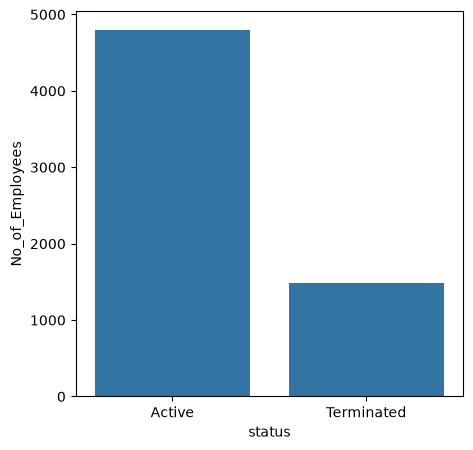

In [47]:
plt.figure(figsize=(5,5))
sns.countplot(df,x='status')
plt.ylabel('No_of_Employees')
plt.show()

2. % of employees in each experience level

In [48]:
val_count = df['Experience_level'].value_counts()
print(val_count.values)
print(val_count.index)

[3825 1846  613]
CategoricalIndex(['Expert', 'Senior', 'Fresher'], categories=['Fresher', 'Senior', 'Expert'], ordered=True, dtype='category', name='Experience_level')


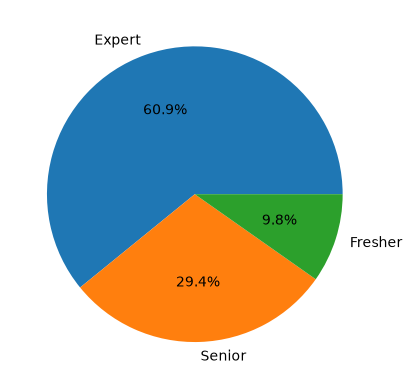

In [49]:
plt.pie(x=val_count.values,autopct='%.1f%%',labels=val_count.index)
plt.show()

3. distrubution of experience 

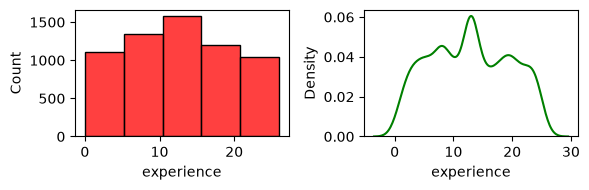

In [50]:
f,a = plt.subplots(nrows=1,ncols= 2,figsize=(6,2)) # a = axes , f = figure
sns.histplot(df,x='experience',bins=5,ax= a[0],color= 'red')
sns.kdeplot(df,x='experience',ax= a[1], color= 'green')
plt.tight_layout()

4. plot the reletionship between age and experience

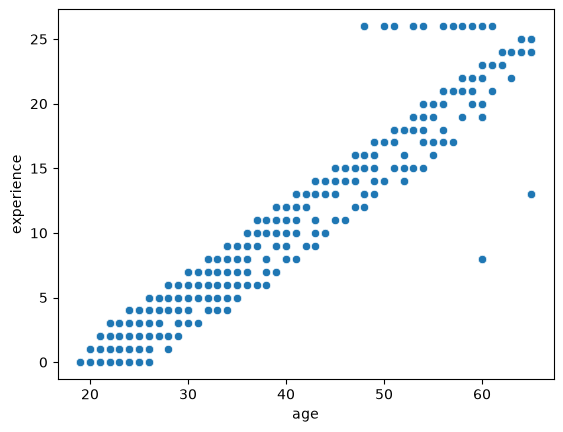

In [51]:
sns.scatterplot(df,x='age',y='experience')
plt.show()

## Observation 
- age and experience have strong positive linear relationship
- Positive mean if x axis data increases y axis data also increase

In [52]:
hire_df = df['hire_date'].dt.year.value_counts().sort_index(ascending=True).reset_index()
# dt.year for extracting the year from date and sort_index is used to sort by year in asce 

In [53]:
hire_df = hire_df.rename(columns={'hire_date': 'hired_year','count' : 'hirings'})
hire_df

,hired_year,hirings
0,1989,86
1,1990,214
2,1991,200
3,1992,248
4,1993,298
5,1994,298
6,1995,312
7,1996,273
8,1997,312
9,1998,341


In [54]:
Terminated_df = df.loc[ df["status"] =="Terminated"]
term_df = Terminated_df['term_date'].dt.year.value_counts().sort_index(ascending=True).reset_index()
term_df = term_df.rename(columns={'term_date': 'term_year','count' : 'term_count'})
term_df

,term_year,term_count
0,2006,134
1,2007,162
2,2008,164
3,2009,142
4,2010,123
5,2011,110
6,2012,130
7,2013,105
8,2014,253
9,2015,162


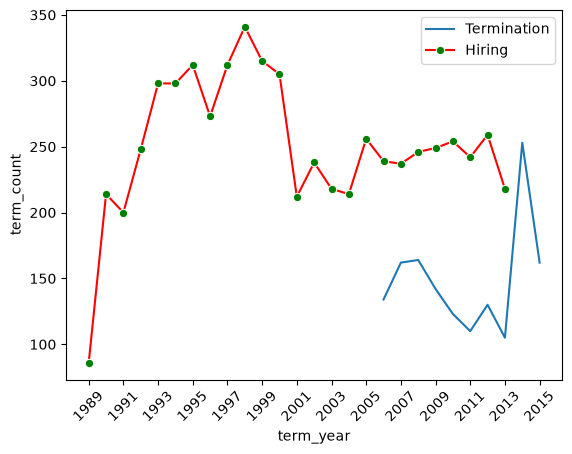

In [55]:
sns.lineplot(term_df,x='term_year',y='term_count',label = 'Termination')

sns.lineplot(hire_df,x='hired_year',y='hirings',
             marker= 'o',
             color ='red',
            markerfacecolor = 'green',
            label = 'Hiring') 
plt.xticks(range(1989,2017,2),rotation = 45)
plt.show()